# Stochastic Discount Factor for US Firm Characteristics

This notebook tests whether an adversarial stochastic discount factor extracts a useful
one-month return signal from firm characteristics and macroeconomic state variables.

**Learning objectives**

- Fit the SDF beta network through sealed walk-forward folds.
- Separate physical training checkpoints from validation-selected aliases.
- Evaluate the fixed final checkpoint with daily rank IC and HAC uncertainty.

**Book reference:** Chapter 14, latent factor models and stochastic discount factors.

**Prerequisites:** `03_financial_features`, `04_evaluation`, and the split contract used by
`05_linear` through `07_tabular_dl`.

In [1]:
"""US firm characteristics SDF case-study run via the shared latent-factor library path."""

import warnings

import matplotlib.pyplot as plt
import polars as pl
from IPython.display import Markdown, display

from case_studies.utils import registry
from case_studies.utils.latent_factors.case_study import (
    configured_models,
    load_case_study_context,
    run_case_study_model,
)
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, add_message_title

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "us_firm_characteristics"
PRIMARY_LABEL = ""
MAX_SYMBOLS = 0
N_FACTORS = 5
N_EPOCHS = 50
USE_CACHE = True
FORCE_RETRAIN = False
MAX_FOLDS = 0
MAX_VARIANT_LABELS = -1
USE_MACRO = True
MODEL_NAME = "sdf"
SEED = 42

## Load the dated modeling surface

The shared context fixes the feature order, ten expanding-window splits, continuous target, and
explicit CUDA runtime. Eleven unrevised daily rate and volatility series enter the macro context
with a one-day availability lag. Finalized weekly, monthly, and quarterly observations are
excluded because they are not point-in-time vintages. The data and macro digests cover only the
union of train and validation dates.

In [3]:
set_global_seeds(SEED)
context = load_case_study_context(
    CASE_STUDY_ID,
    primary_label=PRIMARY_LABEL,
    max_symbols=MAX_SYMBOLS,
    max_folds=MAX_FOLDS,
    max_variant_labels=MAX_VARIANT_LABELS,
    use_macro=USE_MACRO,
)
if MODEL_NAME not in configured_models(context):
    raise ValueError(f"{MODEL_NAME!r} is not configured for {CASE_STUDY_ID}")

print(f"Observations: {len(context.dataset):,}")
print(f"Characteristics: {len(context.feature_names)}")
print(f"Walk-forward folds: {len(context.splits)}")
print(f"Macro state variables: {context.macro_panel.width - 1}")
print(f"Runtime: {context.device}, deterministic={context.deterministic_algorithms}")

Observations: 804,530
Characteristics: 57
Walk-forward folds: 10
Macro state variables: 11
Runtime: cuda, deterministic=True


## Run or replay walk-forward training

The SDF alternates unconditional, conditional, and moment-network phases. Their cumulative epoch
labels form the physical checkpoint surface. The fixed reporting rule uses the final physical
checkpoint. Validation-selected internal aliases remain diagnostics and cannot enter the
reader-facing registry, reported result, or downstream selection. Cached execution requires an
exact match on data, macro vintage, split boundaries, runtime, prediction keys, and reconstructed
daily IC metrics.

In [4]:
result = run_case_study_model(
    context,
    model_name=MODEL_NAME,
    notebook="08c_stochastic_discount_factor",
    n_factors=N_FACTORS,
    n_epochs=N_EPOCHS,
    use_cache=USE_CACHE,
    force_retrain=FORCE_RETRAIN,
)
model_result = result["model_results"][0]
fold_metrics = result["fold_metrics"][MODEL_NAME]

print(f"Reporting epoch: {model_result['best_epoch']}")
print(f"Mean daily rank IC: {model_result['mean_ic']:+.4f}")
print(f"Completed folds: {model_result['n_folds']}")

Latent factor CV: 1 models × 10 folds
Log file: $ML4T_OUTPUT_DIR/us_firm_characteristics/run_log/latent_factors.log
Scoring: dates=rebalance cadence=monthly_month_end step=1 checkpoint_selection=fixed reporting_epoch=last


  sdf: loaded exact registry cohort (IC=+0.0226)
  Best: sdf (IC=+0.0226)
Reporting epoch: 1280
Mean daily rank IC: +0.0226
Completed folds: 10


## Confirm the registered physical checkpoint surface

The registry is the reader-facing source of truth. The query below binds the displayed curve to
the one complete SDF training identity produced by this notebook and excludes internal aliases.

In [5]:
training_runs = registry.load_training_runs(
    CASE_STUDY_ID,
    family="latent_factors",
    label=context.primary_label,
).filter(
    (pl.col("config_name") == MODEL_NAME)
    & (pl.col("entry_point") == "08c_stochastic_discount_factor")
)
if training_runs.height != 1:
    raise ValueError(f"Expected one complete SDF identity, found {training_runs.height}")
training_hash = training_runs["training_hash"][0]

prediction_sets = registry.load_prediction_sets(
    CASE_STUDY_ID,
    training_hash=training_hash,
    split="validation",
)
prediction_metrics = registry.load_prediction_metrics(CASE_STUDY_ID)
checkpoint_summary = (
    prediction_sets.join(prediction_metrics, on="prediction_hash", how="inner")
    .filter(pl.col("checkpoint_value") > 0)
    .sort("checkpoint_value")
    .select(
        pl.col("checkpoint_value").alias("epoch"),
        "ic_mean_daily",
        "ic_ci_lo",
        "ic_ci_hi",
        "ic_p_hac",
        "ic_n_days",
    )
)
checkpoint_summary

epoch,ic_mean_daily,ic_ci_lo,ic_ci_hi,ic_p_hac,ic_n_days
i64,f64,f64,f64,f64,f64
256,-0.011446,-0.027908,0.005016,0.170994,110.0
512,0.009523,-0.010639,0.029685,0.351291,110.0
768,0.020469,-0.008915,0.049853,0.170208,110.0
1024,0.021616,-0.001236,0.044468,0.063498,110.0
1280,0.022554,-0.002767,0.047876,0.080298,110.0


## Pricing-focused training turns mean IC positive

Fold dispersion shows whether the aggregate path depends on one validation period. The final
epoch is fixed before inspecting its IC, while the full physical curve remains diagnostic.

In [6]:
curve = (
    fold_metrics.group_by("epoch")
    .agg(
        pl.col("ic_mean").mean().alias("mean_ic"),
        pl.col("ic_mean").std().alias("fold_std"),
    )
    .sort("epoch")
)
selected_epoch = int(model_result["best_epoch"])
selected = curve.filter(pl.col("epoch") == selected_epoch).row(0, named=True)

The path marks the predeclared final checkpoint and uses fold dispersion to reveal variation
across the ten sealed validation periods.

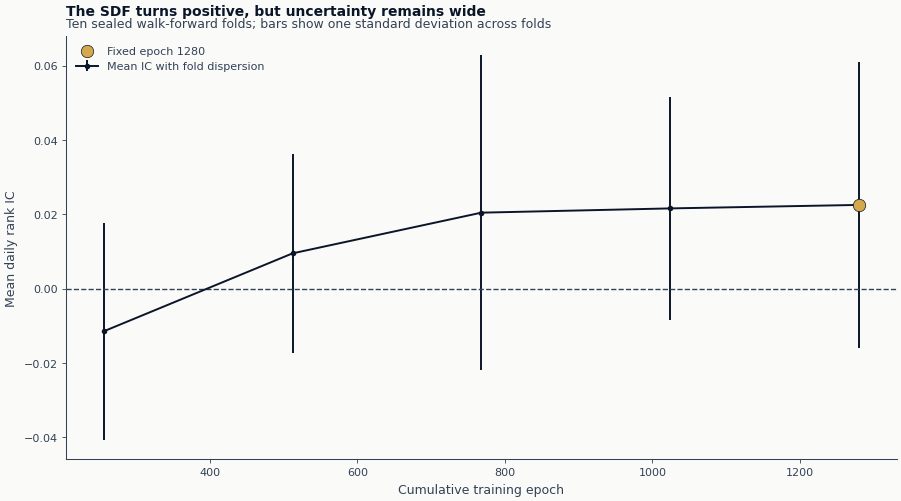

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(
    curve["epoch"],
    curve["mean_ic"],
    yerr=curve["fold_std"],
    color=COLORS["blue"],
    marker="o",
    capsize=3,
    label="Mean IC with fold dispersion",
)
ax.scatter(
    [selected_epoch],
    [selected["mean_ic"]],
    color=COLORS["amber"],
    edgecolor=COLORS["blue"],
    s=80,
    zorder=3,
    label=f"Fixed epoch {selected_epoch}",
)
ax.axhline(0, color=COLORS["neutral"], linewidth=1, linestyle="--")
ax.set(xlabel="Cumulative training epoch", ylabel="Mean daily rank IC")
ax.legend(loc="best")
add_message_title(
    ax,
    "The SDF turns positive, but uncertainty remains wide",
    subtitle="Ten sealed walk-forward folds; bars show one standard deviation across folds",
)
fig.show()

## Takeaways

Validation evidence supports the pricing objective, but model-family selection and final holdout
evaluation remain downstream decisions.

In [8]:
fixed = checkpoint_summary.filter(pl.col("epoch") == selected_epoch).row(0, named=True)
interval_verdict = "excludes" if fixed["ic_ci_lo"] * fixed["ic_ci_hi"] > 0 else "includes"
evidence_verdict = (
    "supports a positive forecasting effect"
    if interval_verdict == "excludes"
    else "does not separate the forecasting effect from zero"
)
display(
    Markdown(
        f"""
- The fixed epoch-{selected_epoch} SDF reaches daily rank IC **{fixed["ic_mean_daily"]:+.4f}**
  across **{int(fixed["ic_n_days"])}** validation months.
- Its HAC 95% interval is **[{fixed["ic_ci_lo"]:+.4f}, {fixed["ic_ci_hi"]:+.4f}]** and
  {interval_verdict} zero, so validation evidence {evidence_verdict}.
- The physical checkpoint path improves from negative to positive IC, while fold dispersion warns
  that the effect is not equally strong in every validation period.
- `08d_supervised_autoencoder` next tests whether direct return supervision strengthens the latent
  representation; Chapter 14 compares these objectives before downstream model selection.
"""
    )
)


- The fixed epoch-1280 SDF reaches daily rank IC **+0.0226**
  across **110** validation months.
- Its HAC 95% interval is **[-0.0028, +0.0479]** and
  includes zero, so validation evidence does not separate the forecasting effect from zero.
- The physical checkpoint path improves from negative to positive IC, while fold dispersion warns
  that the effect is not equally strong in every validation period.
- `08d_supervised_autoencoder` next tests whether direct return supervision strengthens the latent
  representation; Chapter 14 compares these objectives before downstream model selection.
